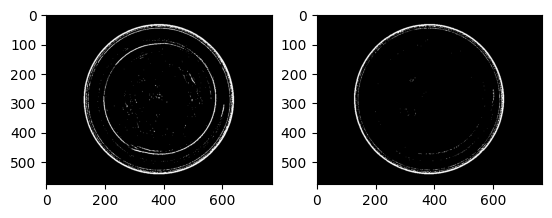

(1, 5, 3)


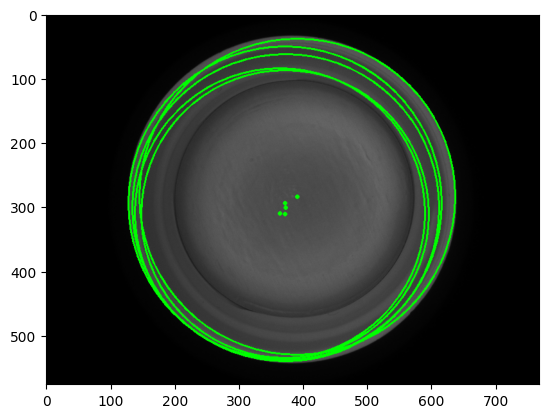

In [ ]:
################################################## PROVA COSE CON ADAPTIVE THRESHOLD PER TROVARE IL LINER ##############################################################


import numpy as np
import cv2
from matplotlib import pyplot as plt

#### LOAD and show IMAGE
img_color_1 = cv2.imread('cap-inspection-images/project_1_liner_inspection/g_06.bmp') 
img_color_2 = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_31.bmp')
img_1_grey = cv2.cvtColor(img_color_1,cv2.COLOR_BGR2GRAY)
img_2_grey = cv2.cvtColor(img_color_2,cv2.COLOR_BGR2GRAY)
img_blur_1 = cv2.GaussianBlur(img_1_grey,(5,5),0)
img_blur_2 = cv2.GaussianBlur(img_2_grey,(5,5),0)
img_1=img_blur_1
img_2=img_blur_2
'''
plt.figure()
plt.subplot(1,2,1)
plt.imshow(img_1,cmap='gray',vmin=0,vmax=255)
plt.subplot(1,2,2)
plt.imshow(img_2,cmap='gray',vmin=0,vmax=255)
plt.show()
'''
#### histogram 
hist_1, bins_1 = np.histogram(img_1.flatten(), 256, [0,256]) #SEMPRE SOTTO 100
hist_2, bins_2 = np.histogram(img_2.flatten(), 256, [0,256])# FINO CIRCA 125/130
'''
plt.figure(2)
plt.subplot(1,2,1)
plt.stem(hist_1)
plt.subplot(1,2,2)
plt.stem(hist_2)
plt.show()
'''
# SE FACCIO ADAPTIVE THRESHOLDING E BINARIZATION CHE MI COMBINA???? ############################################################################


th_1 = cv2.adaptiveThreshold(img_1,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,-1)  
th_2 = cv2.adaptiveThreshold(img_2,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,-1)
# PERCHE NON MI BINARIZZA LO SFONDO TUTTO ATTORNO COME NERO MA ME LO METTE COME BAINCO E FA SOLO IL BORDO DEL TAPPO???????


plt.figure()
plt.subplot(1,2,1)
plt.imshow(th_1,cmap='gray',vmin=0,vmax=255)
plt.subplot(1,2,2)
plt.imshow(th_2,cmap='gray',vmin=0,vmax=255)
plt.show()


'''
hist_th_1, bins_th_1 = np.histogram(th_1.flatten(), 256, [0,256]) #SEMPRE SOTTO 100
plt.figure(2)
plt.subplot(1,2,1)
plt.stem(hist_1)
plt.subplot(1,2,2)
plt.stem(hist_th_1)
plt.show()
'''
#######################################################################################################VERY FUCKING NICE
circles = cv2.HoughCircles(th_1,cv2.HOUGH_GRADIENT, 1, 5,param1=500,param2=85) # ok per trovare esterno dei tappi
# param1: threshold della differenza del gradiente (+alto = colori + diversi)
# param2 : perfezione del cerchio
print(circles.shape)

for c in circles[0,:] : 
    cv2.circle(img_color_1,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)
    cv2.circle(img_color_1,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)
    #print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])

'''
center = (circles[0][0][0],circles[0][0][1])
radius = circles[0][0][2]
cv2.circle(img_color_1,(int(center[0]),int(center[1])),int(radius),color=(0, 255, 0),thickness=2)
cv2.circle(img_color_1,(int(center[0]),int(center[1])),int(2),color=(0, 255, 0),thickness=2)
print("CAP OUTLINE - center: x= ", center[0]," y= ",center[1]," , radius= ",radius )
'''


plt.imshow(img_color_1)
plt.show()

# "flowchart" per fargli fare le varie cose:
carica immagine

trova cerchio grande ---- se non lo trova stampa messaggio di errore

vedi se liner o no ---- se no stop non fai cercare il liner e non fa la task 2 e stampa i risultati

se si : trova il difetto - se c'è fai il riquadro attorno 

crea copia immagine og su cui aggiungere cerchio grande e eventuale riquadro difetto - stampa immagine

se c'è il liner fai task 2 - crea copia immagine og su cui aggiungere cerchio piccolo - stampa immagine


### opzioni per implementarlo
1- 1 immagine per volta: facciamo una var bool / flag per ogni se si se no (liner, difetto) che usiamo sia per decidere se fare certe cose o no e sia per stampare le info a fine task 1

2- tutte immagini loadate e elaborate tutte insieme (ogni step per tutte img): stessa logica di prima ma tenendo tutto in dei mega array

## IDEA PER RISOLVERE LINER INTERNO ALTERNATIVA A USARE IL PARAMETRO DEL MAX RADIUS : 

definiamo una roi dal centro del cerchio del tappo in modo che crei un quadrato inscritto al cerchio del tappo e poi gli facciamo fare la hough solo dentro quella roi. 

roi = [x_max,x_min,y_max,y_min]

con 

x_max=x_centro+radius

x_min=x_centro-radius

y_max=y_centro+radius

y_min=y_centro-radius


# ADAPTIVE THRESHOLDING DOC
[Documentazione OpenCV — Adaptive Thresholding (cv.adaptiveThreshold)](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html)

In the previous section, we used one global value as a threshold. But this might not be good in all cases, e.g. if an image has different lighting conditions in different areas. In that case, adaptive thresholding can help. Here, the algorithm determines the threshold for a pixel based on a small region around it. So we get different thresholds for different regions of the same image which gives better results for images with varying illumination.

In addition to the parameters described above, the method cv.adaptiveThreshold takes three input parameters:

The adaptiveMethod decides how the threshold value is calculated:
cv.ADAPTIVE_THRESH_MEAN_C: The threshold value is the mean of the neighbourhood area minus the constant C.
cv.ADAPTIVE_THRESH_GAUSSIAN_C: The threshold value is a gaussian-weighted sum of the neighbourhood values minus the constant C.

The blockSize determines the size of the neighbourhood area and C is a constant that is subtracted from the mean or weighted sum of the neighbourhood pixels.

Quindi PENULTIMO PARAMETRO: dimensione del neighbourhood con cui confronta il pixel, più lo teniamo alto più cose tiene bianche - da trovare la giusta quota per avere cerchi utili ben definiti ma no info che potrebbero confondere 
questo paramentro va anche scelto in base al parametro scelto per il gaussian blur... più blurro più mi serve di controllare attorno direi 


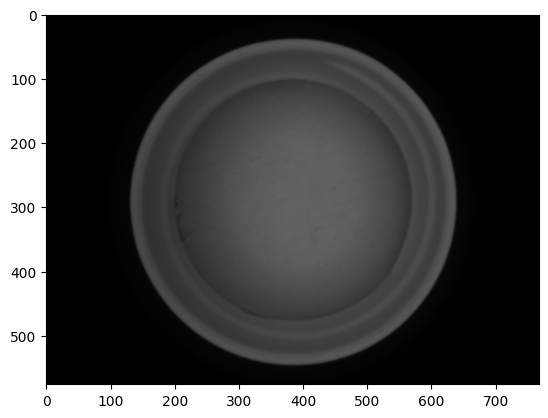

CAP OUTLINE - center: x=  385.5  y=  291.5  , radius=  254.0


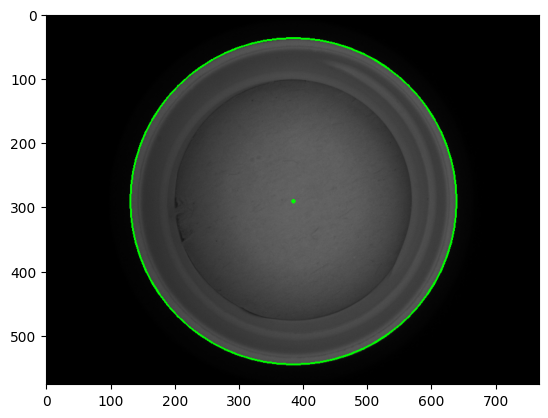

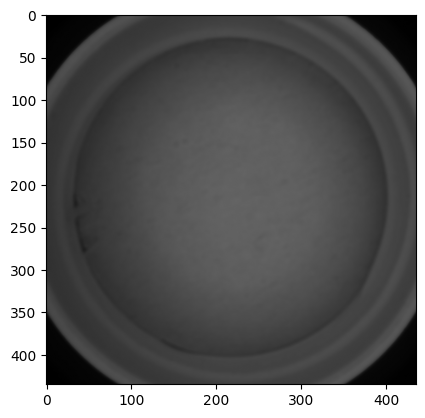

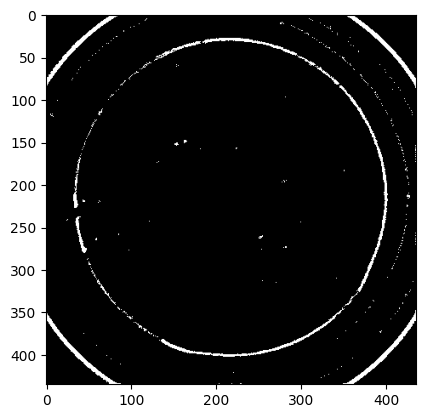

center: x=  225.5  y=  213.5  - radius=  190.2


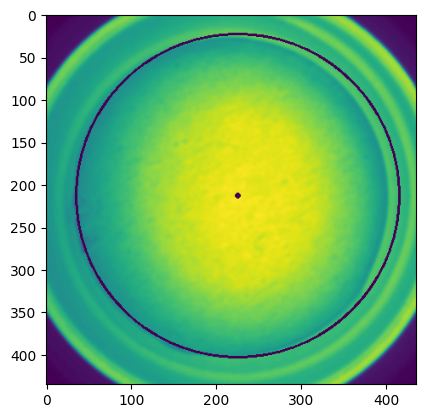

In [76]:
##################################  PROVA ROI + ADAPTIVE THRESHOLDING ##############################

import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

#### LOAD and show IMAGE
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/g_06.bmp')
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_16.bmp')
#img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_31.bmp')
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
#img_blur = cv2.GaussianBlur(img,(7,7),0)
img_blur = cv2.bilateralFilter(img,7,50,75)
plt.figure()
plt.imshow(img_blur,cmap='gray',vmin=0,vmax=255)
plt.show()

#### histogram 
hist, bins = np.histogram(img.flatten(), 256, [0,256])
'''
plt.figure(2,figsize=[8,4])
plt.stem(hist)
plt.show()
'''
######## TASK 1.1:  Outline the cap by generating a circle that fits the cap mouth #########

circles = cv2.HoughCircles(img_blur,cv2.HOUGH_GRADIENT, 1, 45,param1=70,param2=70) # ok per trovare esterno dei tappi
# param1: threshold della differenza del gradiente (+alto = colori + diversi)
# param2 : perfezione del cerchio
#print(circles, circles.shape)
center = (circles[0][0][0],circles[0][0][1])
radius = circles[0][0][2]
'''
for c in circles[0,:] : 
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)
    print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])
'''

######################### NON MI PIACE TROPPO CHE USIAMO SOLO IL PRIMO O LO RIFINIAMO O TROVIAMO UN MODO DI FARE UNA SPECIE DI MEDIA O CI METTIAMO UN ALTRO THRESHOLDING CATTIVISSIMO ANCHE QUA 

cv2.circle(img_color,(int(center[0]),int(center[1])),int(radius),color=(0, 255, 0),thickness=2)
cv2.circle(img_color,(int(center[0]),int(center[1])),int(2),color=(0, 255, 0),thickness=2)
print("CAP OUTLINE - center: x= ", center[0]," y= ",center[1]," , radius= ",radius )

plt.imshow(img_color)
plt.show()


####################################### CREO UNA ROI INSCRITTA AL CERCHIO GRANDE ###################################
'''x_max=math.ceil(center[0]+radius/math.sqrt(2))
x_min=math.floor(center[0]-radius/math.sqrt(2))
y_max=math.ceil(center[1]+radius/math.sqrt(2))
y_min=math.floor(center[1]-radius/math.sqrt(2))
'''############# taglia troppo: anche il cerchio interno 

################################################# provo roi non 100% inscritta o circoscritta ma via di mezzo 
offset = ((radius/math.sqrt(2))+radius)/2
x_max=math.ceil(center[0]+offset)
x_min=math.floor(center[0]-offset)
y_max=math.ceil(center[1]+offset)
y_min=math.floor(center[1]-offset)
########## perfect taglio

in_cap_roi = img_blur[y_min:y_max,x_min:x_max]
plt.imshow(in_cap_roi,cmap='gray',vmin=0,vmax=255)
plt.show()

'''###################### OPZ 1: fai istogramma, trovi valore medio colore e se è sopra una certa soglia  ma è un valore di soglia che dobbiamo trovare manualmente 
hist_roi, bins_roi = np.histogram(in_cap_roi.flatten(), 256, [0,256])
plt.figure(2)
plt.subplot(1,2,1)
plt.stem(hist)
plt.subplot(1,2,2)
plt.stem(hist_roi)
plt.show()
'''


###################### OPZ 2 (pazzerella lucry) : adaptive thresholding trova il cerchio SOLO SE C'È IL LINER  hence se non trova il cerchio non c'è il liner
############################ ffunziona bene con tutte MA SOLO CON PARAM2=34 se lo si alza a 35 non va la 16, se lo si alza oltre non va in generale
########################### provando con al roi ma senza thresholding trova il cerchio esterno se non trova quello interno (d_16 e d_31) -- male ma possiamo usarlo come giustificazione a favore di fare con il thresholding
th_1 = cv2.adaptiveThreshold(in_cap_roi,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,11,2)  
#th_1 = cv2.adaptiveThreshold(in_cap_roi,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,13,2)  ######## test domenica con median blur su th_1
#th_1 = cv2.adaptiveThreshold(in_cap_roi,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,7,2)   # buona se faccio la roi con img_blur

plt.figure()
plt.imshow(th_1,cmap='gray',vmin=0,vmax=255)
plt.show()
'''######## test domenica con median blur su th_1
th_1_blur = cv2.medianBlur(th_1,3)
plt.figure()
plt.imshow(th_1_blur,cmap='gray',vmin=0,vmax=255)
plt.show()
'''

circles = cv2.HoughCircles(th_1,cv2.HOUGH_GRADIENT, 1, int(radius/math.sqrt(2)),param1=50,param2=34) #fare il radius così potrebbe essere un po' un manino 
#circles = cv2.HoughCircles(th_1_blur,cv2.HOUGH_GRADIENT, 1, int(radius/math.sqrt(2)),param1=50,param2=35) ######## test domenica con median blur su th_1
# param1: threshold della differenza del gradiente (+alto = colori + diversi)
# param2 : perfezione del cerchio in questo caso serve più basso per riuscire a prendere anche i cerchi "rovinati"
#print(circles, circles.shape)
center = (circles[0][0][0],circles[0][0][1])
radius = circles[0][0][2]

for c in circles[0,:] : 
    cv2.circle(in_cap_roi,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)
    cv2.circle(in_cap_roi,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)
    print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])
'''

cv2.circle(in_cap_roi,(int(center[0]),int(center[1])),int(radius),color=(0, 255, 0),thickness=2)
cv2.circle(in_cap_roi,(int(center[0]),int(center[1])),int(2),color=(0, 255, 0),thickness=2)
print("CAP OUTLINE - center: x= ", center[0]," y= ",center[1]," , radius= ",radius )
'''
plt.imshow(in_cap_roi)
plt.show()


################################# ALTRA ALTERNATIVA VEDERE SE FACENDO LA ROI ESATTAMENTE INSCRITTA, SENZA IL THRESHOLDING FUNZIONA BENE   ---- no non funziona bene



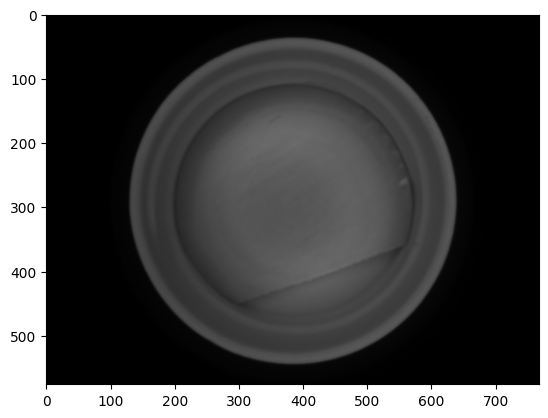

center: x=  383.5  y=  291.5  - radius=  254.2


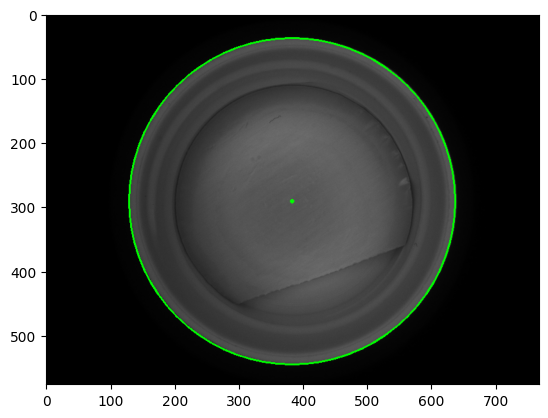

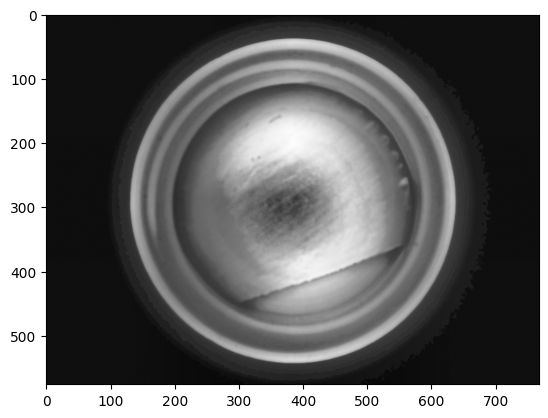

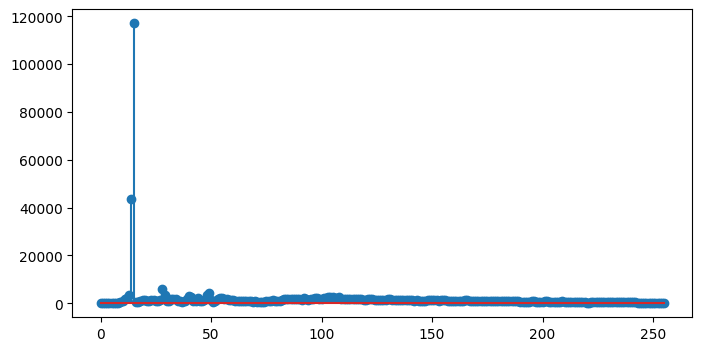

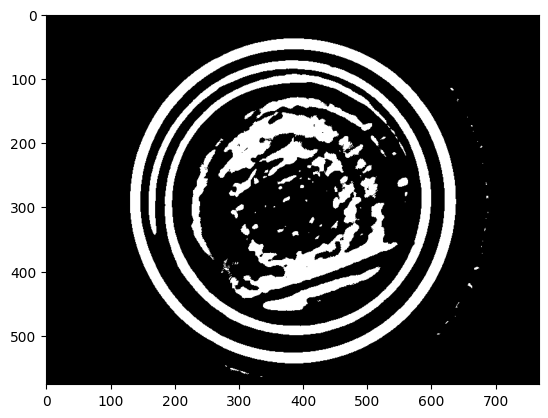

center: x=  385.5  y=  289.5  - radius=  252.4
center: x=  522.5  y=  407.5  - radius=  72.6


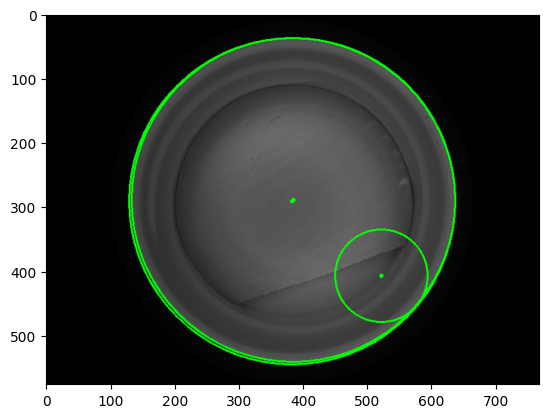

In [ ]:
############################### PROVA CLAHE #################################

import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

### LOAD and show IMAGE
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/g_06.bmp')
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_20.bmp')
#img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_31.bmp')
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
#img_blur = cv2.GaussianBlur(img,(7,7),0)
img_blur = cv2.bilateralFilter(img,7,50,75)
plt.figure()
plt.imshow(img_blur,cmap='gray',vmin=0,vmax=255)
plt.show()

#### histogram 
hist, bins = np.histogram(img.flatten(), 256, [0,256])
'''
plt.figure(2,figsize=[8,4])
plt.stem(hist)
plt.show()
'''
######## TASK 1.1:  Outline the cap by generating a circle that fits the cap mouth #########

circles = cv2.HoughCircles(img_blur,cv2.HOUGH_GRADIENT, 1, 45,param1=70,param2=70) # ok per trovare esterno dei tappi
# param1: threshold della differenza del gradiente (+alto = colori + diversi)
# param2 : perfezione del cerchio
#print(circles, circles.shape)
center = (circles[0][0][0],circles[0][0][1])
radius = circles[0][0][2]

for c in circles[0,:] : 
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)
    print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])


######################### NON MI PIACE TROPPO CHE USIAMO SOLO IL PRIMO O LO RIFINIAMO O TROVIAMO UN MODO DI FARE UNA SPECIE DI MEDIA O CI METTIAMO UN ALTRO THRESHOLDING CATTIVISSIMO ANCHE QUA 

#cv2.circle(img_color,(int(center[0]),int(center[1])),int(radius),color=(0, 255, 0),thickness=2)
#cv2.circle(img_color,(int(center[0]),int(center[1])),int(2),color=(0, 255, 0),thickness=2)
#print("CAP OUTLINE - center: x= ", center[0]," y= ",center[1]," , radius= ",radius )

plt.imshow(img_color)
plt.show()
'''

####################################### CREO UNA ROI INSCRITTA AL CERCHIO GRANDE ###################################
x_max=math.ceil(center[0]+radius/math.sqrt(2))
x_min=math.floor(center[0]-radius/math.sqrt(2))
y_max=math.ceil(center[1]+radius/math.sqrt(2))
y_min=math.floor(center[1]-radius/math.sqrt(2))
############# taglia troppo: anche il cerchio interno 

################################################# provo roi non 100% inscritta o circoscritta ma via di mezzo 
offset = ((radius/math.sqrt(2))+radius)/2
x_max=math.ceil(center[0]+offset)
x_min=math.floor(center[0]-offset)
y_max=math.ceil(center[1]+offset)
y_min=math.floor(center[1]-offset)
########## perfect taglio

in_cap_roi = img_blur[y_min:y_max,x_min:x_max]
plt.imshow(in_cap_roi,cmap='gray',vmin=0,vmax=255)
plt.show()

'''
clahe = cv2.createCLAHE(clipLimit=14.0, tileGridSize=(3,3))
cl1 = clahe.apply(img_blur)


plt.figure()
plt.imshow(cl1,cmap='gray',vmin=0,vmax=255)
plt.show()

#### histogram 
hist_cl, bins_cl = np.histogram(cl1.flatten(), 256, [0,256])

plt.figure(4,figsize=[8,4])
plt.stem(hist_cl)
plt.show()

cl1_blur = cv2.bilateralFilter(cl1,7,75,75)
th_1 = cv2.adaptiveThreshold(cl1_blur,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,45,-5)  
#th_1 = cv2.adaptiveThreshold(in_cap_roi,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,7,2)   # buona se faccio la roi con img_blur

plt.figure()
plt.imshow(th_1,cmap='gray',vmin=0,vmax=255)
plt.show()


circles = cv2.HoughCircles(th_1,cv2.HOUGH_GRADIENT, 1, int(radius/math.sqrt(2)),param1=50,param2=34) #fare il radius così potrebbe essere un po' un manino 
# param1: threshold della differenza del gradiente (+alto = colori + diversi)
# param2 : perfezione del cerchio in questo caso serve più basso per riuscire a prendere anche i cerchi "rovinati"
#print(circles, circles.shape)
center = (circles[0][0][0],circles[0][0][1])
radius = circles[0][0][2]

for c in circles[0,:] : 
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)
    print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])
'''

cv2.circle(in_cap_roi,(int(center[0]),int(center[1])),int(radius),color=(0, 255, 0),thickness=2)
cv2.circle(in_cap_roi,(int(center[0]),int(center[1])),int(2),color=(0, 255, 0),thickness=2)
print("CAP OUTLINE - center: x= ", center[0]," y= ",center[1]," , radius= ",radius )
'''
plt.imshow(img_color)
plt.show()



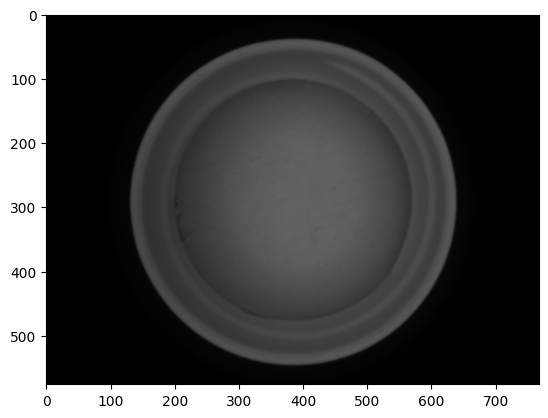

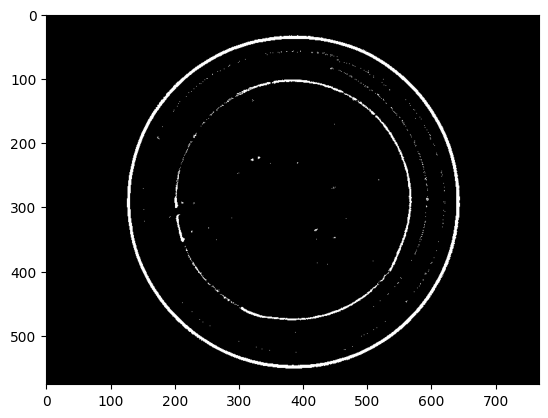

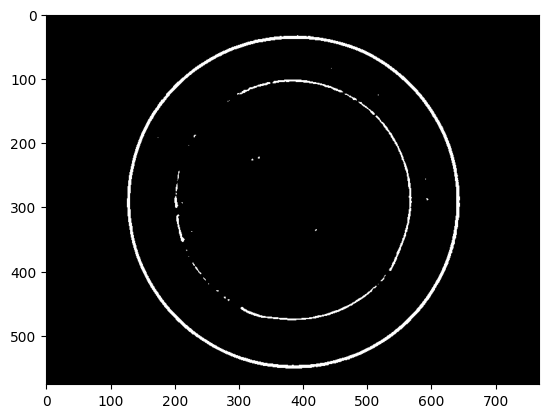

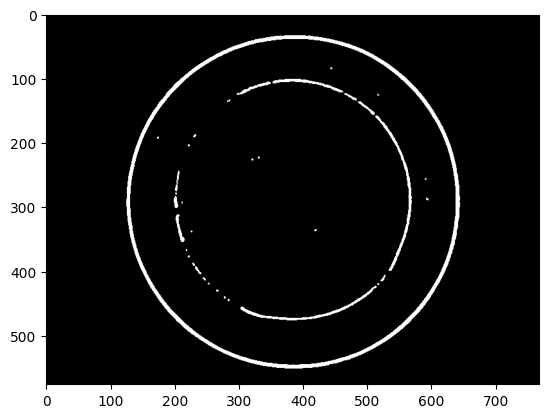

TypeError: 'NoneType' object is not subscriptable

In [61]:
##################################  PROVA ROI + ADAPTIVE THRESHOLDING ##############################

import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

#### LOAD and show IMAGE
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/g_06.bmp')
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_16.bmp')
#img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_31.bmp')
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
#img_blur = cv2.GaussianBlur(img,(7,7),0)
img_blur = cv2.bilateralFilter(img,7,50,75)
plt.figure()
plt.imshow(img_blur,cmap='gray',vmin=0,vmax=255)
plt.show()

#### histogram 
hist, bins = np.histogram(img.flatten(), 256, [0,256])
'''
plt.figure(2,figsize=[8,4])
plt.stem(hist)
plt.show()
'''

img_bin = cv2.adaptiveThreshold(img_blur,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,11,2)  
#th_1 = cv2.adaptiveThreshold(in_cap_roi,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,7,2)   # buona se faccio la roi con img_blur

plt.figure()
plt.imshow(img_bin,cmap='gray',vmin=0,vmax=255)
plt.show()


#what if i used canny as a edge enhencer
img_bin_blur = cv2.medianBlur(img_bin,3)
plt.figure()
plt.imshow(img_bin_blur,cmap='gray',vmin=0,vmax=255)
plt.show()

img_bin_canny=cv2.Canny(img_bin_blur,100,200)
img_bin_enhanced=img_bin_canny+img_bin_blur
plt.figure()
plt.imshow(img_bin_enhanced,cmap='gray',vmin=0,vmax=255)
plt.show()

######## TASK 1.1:  Outline the cap by generating a circle that fits the cap mouth #########

circles = cv2.HoughCircles(img_bin_enhanced,cv2.HOUGH_GRADIENT, 1, 1,param1=700,param2=62) # ok per trovare esterno dei tappi
# param1: threshold della differenza del gradiente (+alto = colori + diversi)
# param2 : perfezione del cerchio
#print(circles, circles.shape)
center = (circles[0][0][0],circles[0][0][1])
radius = circles[0][0][2]

for c in circles[0,:] : 
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)
    print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])


######################### NON MI PIACE TROPPO CHE USIAMO SOLO IL PRIMO O LO RIFINIAMO O TROVIAMO UN MODO DI FARE UNA SPECIE DI MEDIA O CI METTIAMO UN ALTRO THRESHOLDING CATTIVISSIMO ANCHE QUA 

cv2.circle(img_color,(int(center[0]),int(center[1])),int(radius),color=(0, 255, 0),thickness=2)
cv2.circle(img_color,(int(center[0]),int(center[1])),int(2),color=(0, 255, 0),thickness=2)
print("CAP OUTLINE - center: x= ", center[0]," y= ",center[1]," , radius= ",radius )

plt.imshow(img_color)
plt.show()

